# Задача №2: рабочая GP-карта Qwen

In [1]:
%pip -q install "transformers==5.3.0" "datasets>=4,<5" "accelerate>=1.12,<2" "scikit-learn==1.6.1" "scipy>=1.13,<2" "pandas>=2,<3" "matplotlib>=3.8,<4" "umap-learn==0.5.12" "threadpoolctl>=3,<4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 62.9 MB/s eta 0:00:00


## 1. Настройки

`domains` — предметы MMLU, `samples_per_domain` — запрашиваемое число текстов каждого. `domains="all"` выбирает каталог из 57 предметов. Если нужен другой Hugging Face источник, заполните `domain_sources` списком словарей: `domain`, `path`, `name` (если нужен), `split`, `revision`, `text_field`. У каждого домена может быть свой датасет; при непустом списке MMLU-ветка не используется.

Кластерный старт включён: 4 кластера × 1 ближайшая точка на предмет. `n_clusters` и `points_per_cluster` реально меняют отбор. Для старта 4×5 установите `points_per_cluster=5` и увеличьте `search["budget"]` хотя бы до 120 (например, 192): бюджет включает старт. `initial_strategy="random"` возвращает старт из предыдущих экспериментов; тогда используется `initial_per_domain`.

Карта: Matérn с шумом / raw / random. Поиск: RBF (`legacy`) / raw / UCB κ=5. В каждой ветке можно изменить ядро, `target_transform` (`raw`/`log`) и `acquisition` (`random`/`mean`/`uncertainty`/`ucb`). Для UCB задайте `kappa`. `gp_mode="per_domain"` — отдельные GP для контрольного сравнения.

`validate=True` **после фиксации решений** дополнительно измерит 120 validation и 120 test текстов. При `False` карта и поиск работают без контрольных JSD, качество неизвестно. Общие затраты выводятся отдельно. Для сохранения кэша между сессиями можно указать путь на заранее подключённом Google Drive.

In [2]:
import copy, contextlib, hashlib, json, time, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import pdist,cdist
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,Matern,ConstantKernel,WhiteKernel
from threadpoolctl import threadpool_limits
from IPython.display import display

config = {'teacher': 'Qwen/Qwen3.5-2B-Base',
 'student': 'Qwen/Qwen3.5-0.8B-Base',
 'teacher_revision': 'b1485b2fa6dfa1287294f269f5fb618e03d52d7c',
 'student_revision': 'dc7cdfe2ee4154fa7e30f5b51ca41bfa40174e68',
 'dtype': 'float16',
 'max_length': 256,
 'top_k': 30,
 'dataset': 'cais/mmlu',
 'dataset_revision': 'c30699e8356da336a370243923dbaf21066bb9fe',
 'dataset_split': 'test',
 'domains': ['abstract_algebra',
             'anatomy',
             'astronomy',
             'college_computer_science',
             'high_school_mathematics',
             'professional_law'],
 'domain_sources': [],
 'samples_per_domain': 100,
 'pool_seed': 42,
 'seed': 100,
 'validation_per_domain': 20,
 'test_per_domain': 20,
 'initial_strategy': 'cluster',
 'n_clusters': 4,
 'points_per_cluster': 1,
 'initial_per_domain': 4,
 'gp_mode': 'global',
 'epsilon': 0.05,
 'log_eps': 1e-08,
 'alpha': 1e-06,
 'normalize_y': True,
 'gp_restarts': 0,
 'posterior_draws': 256,
 'map': {'kernel': 'matern_noise',
         'target_transform': 'raw',
         'acquisition': 'random',
         'budget': 192},
 'search': {'kernel': 'legacy',
            'target_transform': 'raw',
            'acquisition': 'ucb',
            'kappa': 5.0,
            'budget': 96},
 'acquisition_batch': 6,
 'top_texts_per_domain': 10,
 'validate': True,
 'compare_policies': False,
 'kappa_values': [1, 2, 5, 10],
 'plot_umap': True,
 'large_target_test': False,
 'output_dir': '/content/qwen_task2_live',
 'cache_dir': '/content/qwen_task2_cache',
 'code_version': '381ac576ca27e76e176a5e3ab0cfe5271497b52351dbd487dafa41590b3a9dc5'}
if not Path('/content').exists():
    config['output_dir']='qwen_task2_live'
    config['cache_dir']='qwen_task2_cache'
random.seed(config['seed']);np.random.seed(config['seed']);torch.manual_seed(config['seed'])
print('Training labels: map',config['map']['budget'],'; search',config['search']['budget'])
print('These are separate branch budgets; physical teacher calls are counted separately.')

Training labels: map 192 ; search 96
These are separate branch budgets; physical teacher calls are counted separately.


## 2. Данные и метрика

MMLU загружается streaming с reservoir sampling, текст — question + choices + `Answer:`, без правильного ответа. Совпадающие видимые token-ID префиксы удаляются до split. Число фактически доступных текстов сохраняется; недостаточный набор не дополняется дублями.

JSD: на каждой позиции объединяем top-30 teacher/student, ренормируем вероятности на объединении и считаем стандартную JSD с натуральным логарифмом. Усредняем по действительным позициям. В plan.md неоднозначный лишний множитель 1/2; второй раз делить уже стандартную JSD не стали. Пределы длины в plan.md расходятся (512/128); оставлен проверенный общий видимый префикс 256 токенов. Это явно выбранная конфигурация, а не утверждение о буквальном выполнении обоих ограничений.

В исходном плане также 500 текстов и 200 holdout на предмет. Некоторые MMLU subjects имеют только 100 test-вопросов: текущий рабочий профиль — 100 и 20+20, а параметры большего масштаба доступны для достаточных источников.

Признаки — среднее последнего hidden state student в float32, L2. Teacher для признаков не запускается; student всё равно проходит весь пул. После изменения student его признаки и JSD должны быть пересчитаны для новой ревизии.

In [3]:
MMLU_SUBJECTS = ['abstract_algebra', 'anatomy', 'astronomy', 'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 'college_computer_science', 'college_mathematics', 'college_medicine', 'college_physics', 'computer_security', 'conceptual_physics', 'econometrics', 'electrical_engineering', 'elementary_mathematics', 'formal_logic', 'global_facts', 'high_school_biology', 'high_school_chemistry', 'high_school_computer_science', 'high_school_european_history', 'high_school_geography', 'high_school_government_and_politics', 'high_school_macroeconomics', 'high_school_mathematics', 'high_school_microeconomics', 'high_school_physics', 'high_school_psychology', 'high_school_statistics', 'high_school_us_history', 'high_school_world_history', 'human_aging', 'human_sexuality', 'international_law', 'jurisprudence', 'logical_fallacies', 'machine_learning', 'management', 'marketing', 'medical_genetics', 'miscellaneous', 'moral_disputes', 'moral_scenarios', 'nutrition', 'philosophy', 'prehistory', 'professional_accounting', 'professional_law', 'professional_medicine', 'professional_psychology', 'public_relations', 'security_studies', 'sociology', 'us_foreign_policy', 'virology', 'world_religions']
print("MMLU subjects:",len(MMLU_SUBJECTS))

MMLU subjects: 57


## 3. Реализация


Log-режим использует log(JSD+δ); обратное среднее exp(μz+σz²/2)−δ, а θ — CDF с порогом log(ε+δ). Плохой R² и почти постоянный прогноз отмечаются, но не прерывают сохранение результатов и не выбирают модель автоматически.

In [4]:
#@title GP, JSD и загрузка данных
def fingerprint(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, ensure_ascii=False).encode()).hexdigest()

def save_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

def stats(x):
    x = np.asarray(x, dtype=float)
    assert x.size and np.isfinite(x).all()
    return {"n": int(x.size), "min": float(x.min()), "max": float(x.max()),
            "mean": float(x.mean()), "std": float(x.std()), "variance": float(x.var()),
            "quantiles": np.quantile(x, [0, .05, .25, .5, .75, .95, 1]).tolist()}

def transform_target(y, mode, eps):
    y = np.asarray(y, dtype=float)
    assert np.isfinite(y).all() and (y >= 0).all()
    result = np.log(y + eps) if mode == "log" else y.copy()
    assert np.isfinite(result).all(), "Nonfinite target after transform"
    return result

def prediction_moments(mu, sigma, mode, log_eps, epsilon):
    # Log model: E[JSD] != exp(E[log(JSD+eps)]). Use shifted-lognormal moments.
    sigma = np.maximum(np.asarray(sigma), 0)
    if mode == "log":
        with np.errstate(over="raise", invalid="raise"):
            mean = np.exp(mu + sigma**2 / 2) - log_eps
            std = np.sqrt(np.expm1(sigma**2) * np.exp(2 * mu + sigma**2))
        threshold = np.log(epsilon + log_eps)
    else:
        mean, std, threshold = mu, sigma, epsilon
    probability = norm.cdf((threshold - mu) / np.maximum(sigma, 1e-12))
    probability = np.where(sigma <= 1e-12, (mu <= threshold).astype(float), probability)
    assert np.isfinite(mean).all() and np.isfinite(std).all()
    return mean, std, probability

def make_kernel(X, spec):
    if spec["kernel"] == "legacy":
        return RBF(.5, (.1, 2.))
    distances = pdist(X)
    distance = float(np.median(distances[distances > 1e-12])) if np.any(distances > 1e-12) else 1.
    signal = RBF(distance, (distance / 10, distance * 10))
    if spec["kernel"] == "distance_rbf":
        return signal
    if spec["kernel"] == "signal_noise_rbf":
        return ConstantKernel(1., (.01, 100.)) * signal + WhiteKernel(.01, (1e-6, 1.))
    if spec["kernel"] == "matern_noise":
        return ConstantKernel(1., (.01, 100.)) * Matern(distance, (distance / 10, distance * 10), nu=1.5) + WhiteKernel(.01, (1e-6, 1.))
    raise ValueError(spec["kernel"])

def fit_models(X, domains, labeled, y, spec, cfg, seed):
    models, details = {}, {}
    groups = ["__global__"] if spec["gp_mode"] == "global" else sorted(set(domains))
    for group in groups:
        indices = labeled if group == "__global__" else labeled[domains[labeled] == group]
        raw = y[indices]
        target = transform_target(raw, spec["target_transform"], cfg["log_eps"])
        kernel = make_kernel(X[indices], spec)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=spec["alpha"],
             normalize_y=spec["normalize_y"], n_restarts_optimizer=cfg["gp_restarts"], random_state=seed)
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            gp.fit(X[indices], target)
        warnings_text = list(dict.fromkeys(str(w.message) for w in caught))
        model_parameters = {k: np.asarray(v).tolist() for k, v in gp.kernel_.get_params().items()
                            if k.endswith(("length_scale", "noise_level", "constant_value"))}
        at_bound = bool(np.any(np.isclose(gp.kernel_.theta, gp.kernel_.bounds[:, 0], atol=1e-4)) or
                        np.any(np.isclose(gp.kernel_.theta, gp.kernel_.bounds[:, 1], atol=1e-4)))
        details[group] = dict(kernel_initial=str(kernel), kernel_final=str(gp.kernel_),
            optimized_parameters=model_parameters, log_bounds=gp.kernel_.bounds.tolist(),
            at_bound=at_bound, alpha=spec["alpha"], normalize_y=spec["normalize_y"],
            target_raw=stats(raw), target_transformed=stats(target),
            n_train=len(indices), n_unique_X=int(len(np.unique(X[indices], axis=0))),
            train_distance=stats(pdist(X[indices])), warnings=warnings_text,
            log_marginal_likelihood=float(gp.log_marginal_likelihood_value_))
        models[group] = (gp, indices)
    return models, details

def predict_models(models, X, domains, indices, spec, cfg):
    mu, sigma = np.empty(len(indices)), np.empty(len(indices))
    for group, (gp, _) in models.items():
        mask = np.ones(len(indices), dtype=bool) if group == "__global__" else domains[indices] == group
        if mask.any():
            mu[mask], sigma[mask] = gp.predict(X[indices[mask]], return_std=True)
    mean, std, probability = prediction_moments(mu, sigma, spec["target_transform"], cfg["log_eps"], cfg["epsilon"])
    return dict(mu=mean, sigma=std, probability=probability, latent_mu=mu, latent_sigma=sigma)

def quality(y, pred, train_y, epsilon):
    mu, sigma = pred["mu"], pred["sigma"]
    residual = y - mu
    denominator = float(np.sum((y - y.mean())**2))
    r2 = 1 - float(np.sum(residual**2)) / denominator if denominator > 1e-20 else None
    measured_std, predicted_std = float(y.std()), float(mu.std())
    flags = []
    if predicted_std < 1e-6 or (measured_std > 1e-6 and predicted_std / measured_std < .01):
        flags.append("nearly_constant_prediction")
    if measured_std < 1e-6:
        flags.append("nearly_constant_target")
    if r2 is not None and r2 <= 0:
        flags.append("nonpositive_r2")
    return dict(n=len(y), mae=float(np.abs(residual).mean()), rmse=float(np.sqrt(np.mean(residual**2))),
        r2=r2, measured_mean=float(y.mean()), measured_std=measured_std,
        predicted_mean=float(mu.mean()), predicted_std=predicted_std,
        sigma_mean=float(sigma.mean()), sigma_std=float(sigma.std()),
        train_mean_baseline_mae=float(np.abs(y - train_y.mean()).mean()),
        theta=float(pred["probability"].mean()), empirical_theta=float((y <= epsilon).mean()),
        theta_abs_error=float(abs(pred["probability"].mean() - (y <= epsilon).mean())),
        brier=float(np.mean((pred["probability"] - (y <= epsilon))**2)),
        outside_js_range_fraction=float(((mu < 0) | (mu > np.log(2))).mean()), flags=flags)

def evaluate(models, X, domains, indices, labeled, y, spec, cfg):
    pred = predict_models(models, X, domains, indices, spec, cfg)
    metrics = {"__all__": quality(y[indices], pred, y[labeled], cfg["epsilon"])}
    for domain in sorted(set(domains[indices])):
        mask = domains[indices] == domain
        train = labeled[domains[labeled] == domain]
        metrics[domain] = quality(y[indices[mask]], {k: v[mask] for k, v in pred.items()}, y[train], cfg["epsilon"])
    return metrics, pred

def correlation_diagnostics(models, X, domains, holdout):
    details = {}
    for group, (gp, train) in models.items():
        probe = holdout if group == "__global__" else holdout[domains[holdout] == group]
        distances = cdist(X[probe], X[train])
        # Cross-covariance excludes WhiteKernel's diagonal observation noise.
        covariance = gp.kernel_(X[probe], X[train])
        diagonal = np.sqrt(gp.kernel_.diag(X[probe])[:, None] * gp.kernel_.diag(X[train])[None, :])
        correlation = covariance / np.maximum(diagonal, 1e-30)
        details[group] = dict(nearest_train_distance=stats(distances.min(axis=1)),
            max_train_kernel_correlation=stats(correlation.max(axis=1)),
            fraction_effectively_disconnected=float((correlation.max(axis=1) < 1e-6).mean()))
    return details

def load_mmlu(cfg, output):
    from datasets import get_dataset_config_names, load_dataset
    from huggingface_hub import HfApi
    revision = HfApi().dataset_info(cfg["dataset"], revision=cfg["dataset_revision"]).sha
    available = sorted(set(get_dataset_config_names(cfg["dataset"], revision=revision)) - {"all", "auxiliary_train"})
    save_json(output / "mmlu_subjects.json", available)
    subjects = available if cfg["domains"] == "all" else cfg["domains"]
    records, metadata, seen = [], {}, set()
    for subject in subjects:
        # Reservoir sampling visits the selected subject split once and samples uniformly.
        # No shuffle-buffer prefix bias; no auxiliary_train or gold answers in the prompt.
        ds = load_dataset(cfg["dataset"], subject, split=cfg["dataset_split"], revision=revision, streaming=True)
        rng = np.random.default_rng(cfg["pool_seed"] + int(fingerprint(subject)[:8], 16))
        reservoir, eligible, duplicates = [], 0, 0
        for row_index, row in enumerate(ds):
            text = row["question"].strip() + "\n" + "\n".join(
                f"{chr(65 + j)}. {choice}" for j, choice in enumerate(row["choices"])) + "\nAnswer:"
            key = fingerprint(text)
            if key in seen:
                duplicates += 1
                continue
            seen.add(key)
            item = dict(id=fingerprint([revision, subject, row_index]), domain=subject,
                        text=text, source_row=row_index, source_split=cfg["dataset_split"])
            eligible += 1
            if len(reservoir) < cfg["samples_per_domain"]:
                reservoir.append(item)
            else:
                j = int(rng.integers(eligible))
                if j < cfg["samples_per_domain"]:
                    reservoir[j] = item
        records.extend(sorted(reservoir, key=lambda r: r["source_row"]))
        metadata[subject] = dict(available_unique=eligible, sampled=len(reservoir), duplicates_skipped=duplicates)
        print(f"{subject}: {len(reservoir)} / {eligible} eligible examples", flush=True)
    save_json(output / "pool.json", records)
    save_json(output / "dataset.json", dict(dataset=cfg["dataset"], revision=revision,
              split=cfg["dataset_split"], subjects=metadata, prompt="question + choices + Answer:, without gold answer"))
    return records, revision

def truncated_js(logits_a, logits_b, k=30):
    """JS на объединении top-k; форма входа (..., vocab), выхода (...)."""
    support = torch.cat((logits_a.topk(k).indices, logits_b.topk(k).indices), dim=-1).sort().values
    unique = torch.ones_like(support, dtype=torch.bool)
    unique[..., 1:] = support[..., 1:] != support[..., :-1]
    # Softmax на выбранных логитах равен полной softmax с последующей перенормировкой.
    p = logits_a.gather(-1, support).float().masked_fill(~unique, -torch.inf).softmax(-1)
    q = logits_b.gather(-1, support).float().masked_fill(~unique, -torch.inf).softmax(-1)
    m = (p + q) / 2
    return 0.5 * (p * ((p + 1e-30).log() - (m + 1e-30).log())
                  + q * ((q + 1e-30).log() - (m + 1e-30).log())).sum(-1)

In [5]:
#@title Рабочий pipeline и кэш
"""Live task 2: only selected texts are sent to the teacher; no full-label input."""
import gc
import io
import zipfile
from importlib.metadata import version


def load_sources(cfg,out):
    if not cfg['domain_sources']:
        records,revision=load_mmlu(cfg,out)
        return records
    from datasets import load_dataset
    from huggingface_hub import HfApi
    records=[];seen=set();metadata=[]
    for source in cfg['domain_sources']:
        domain=source['domain'];revision=HfApi().dataset_info(source['path'],revision=source['revision']).sha
        stream=load_dataset(source['path'],source.get('name'),split=source['split'],revision=revision,streaming=True)
        rng=np.random.default_rng(cfg['pool_seed']+int(fingerprint(domain)[:8],16));sample=[];eligible=0
        for row_index,row in enumerate(stream):
            text=str(row[source['text_field']]).strip()
            if not text or fingerprint(text) in seen:continue
            seen.add(fingerprint(text));eligible+=1
            record=dict(id=fingerprint([source['path'],revision,source.get('name'),source['split'],row_index]),
                domain=domain,text=text,source_row=row_index,source_split=source['split'])
            if len(sample)<cfg['samples_per_domain']:sample.append(record)
            else:
                j=int(rng.integers(eligible))
                if j<cfg['samples_per_domain']:sample[j]=record
        records.extend(sorted(sample,key=lambda r:r['source_row']))
        metadata.append(dict(**source,resolved_revision=revision,available=eligible,sampled=len(sample)))
        print(domain,len(sample),'/',eligible,flush=True)
    save_json(out/'dataset.json',metadata)
    return records


def live_split(X,domains,cfg):
    rng=np.random.default_rng(cfg['seed']);parts={k:[] for k in ('train','validation','test','initial')};fallback=[]
    for domain in sorted(set(domains)):
        ids=rng.permutation(np.flatnonzero(domains==domain));nv=cfg['validation_per_domain'];nt=cfg['test_per_domain']
        candidates=ids[nv+nt:]
        count=cfg['initial_per_domain'] if cfg['initial_strategy']=='random' else cfg['n_clusters']*cfg['points_per_cluster']
        if nv<1 or nt<2 or len(candidates)<count:
            raise ValueError(f'{domain}: {len(ids)} texts cannot provide validation={nv}, test={nt}, initial={count}. Change the sample size or holdouts.')
        parts['validation'].extend(ids[:nv]);parts['test'].extend(ids[nv:nv+nt]);parts['train'].extend(candidates)
        if cfg['initial_strategy']=='random':chosen=candidates[:count]
        elif cfg['initial_strategy']=='cluster':
            km=KMeans(n_clusters=cfg['n_clusters'],n_init=10,random_state=cfg['seed']).fit(X[candidates])
            chosen=[]
            for cluster,center in enumerate(km.cluster_centers_):
                members=candidates[km.labels_==cluster];distance=np.linalg.norm(X[members]-center,axis=1)
                chosen.extend(members[np.lexsort((members,distance))[:cfg['points_per_cluster']]])
            # A small/empty cluster must not silently shrink the starting budget.
            if len(chosen)<count:
                remaining=np.setdiff1d(candidates,chosen);distance=cdist(X[remaining],km.cluster_centers_).min(1)
                extra=remaining[np.lexsort((remaining,distance))[:count-len(chosen)]];chosen.extend(extra);fallback.extend(extra)
        else:raise ValueError('initial_strategy: random or cluster')
        parts['initial'].extend(chosen)
    split={k:np.array(v,dtype=int) for k,v in parts.items()}
    for branch in ('map','search'):
        if not len(split['initial'])<=cfg[branch]['budget']<=len(split['train']):
            raise ValueError(f'{branch}: initial={len(split["initial"])}, budget={cfg[branch]["budget"]}, train={len(split["train"])}. Budgets include the initial points.')
    return split,fallback


class QwenMeasurements:
    """Caches features by student/token IDs and JSD by teacher/student/token IDs."""
    def __init__(self,cfg,records,cache):
        import torch
        from transformers import AutoTokenizer
        from huggingface_hub import HfApi
        if not torch.cuda.is_available():raise RuntimeError('Use a Colab GPU T4 for the live Qwen notebook.')
        self.cfg=cfg;self.cache=Path(cache);self.cache.mkdir(parents=True,exist_ok=True)
        self.revisions={role:HfApi().model_info(cfg[role],revision=cfg[role+'_revision']).sha for role in ('teacher','student')}
        tok=AutoTokenizer.from_pretrained(cfg['teacher'],revision=self.revisions['teacher'])
        other=AutoTokenizer.from_pretrained(cfg['student'],revision=self.revisions['student'])
        if tok.get_vocab()!=other.get_vocab():raise ValueError('Teacher/student token vocabularies are not aligned.')
        self.records=[];self.tokens=[];seen=set();dropped=[];lengths=[]
        for record in records:
            full=tok(record['text'],add_special_tokens=True)['input_ids'];ids=full[:cfg['max_length']]
            if ids!=other(record['text'],add_special_tokens=True)['input_ids'][:cfg['max_length']]:raise ValueError('Visible teacher/student token IDs differ.')
            key=fingerprint(ids)
            if key in seen:dropped.append(record['id']);continue
            seen.add(key);self.records.append(record);self.tokens.append(ids);lengths.append(len(full))
        self.input_info=dict(tokens=stats(lengths),truncated=sum(n>cfg['max_length'] for n in lengths),duplicate_prefixes_removed=dropped)
        self.identity=dict(models={role:dict(id=cfg[role],revision=self.revisions[role]) for role in ('teacher','student')},
            top_k=cfg['top_k'],max_length=cfg['max_length'],dtype=cfg['dtype'],metric='union_topk_js_all_positions_v1',
            versions={p:version(p) for p in ('torch','transformers')})
        self.keys=[fingerprint([ids,self.identity]) for ids in self.tokens]
        self.js_path=self.cache/('jsd_'+fingerprint(self.identity)[:20]+'.json')
        self.values=json.loads(self.js_path.read_text(encoding='utf-8')) if self.js_path.exists() else {}
        self.student=None;self.teacher=None;self.physical_jsd_calls=0;self.feature_calls=0
        self.feature_seconds=0.;self.measure_seconds=0.

    def model(self,role):
        import torch
        from transformers import AutoModelForCausalLM
        if getattr(self,role) is None:
            print('Loading',role,self.cfg[role],flush=True)
            setattr(self,role,AutoModelForCausalLM.from_pretrained(self.cfg[role],revision=self.revisions[role],
                dtype=getattr(torch,self.cfg['dtype']),device_map={'':0},attn_implementation='sdpa').eval())
        return getattr(self,role)

    def inputs(self,index):
        import torch
        ids=torch.tensor([self.tokens[index]],device='cuda')
        return dict(input_ids=ids,attention_mask=torch.ones_like(ids))

    def features(self):
        import torch
        identity=dict(student=self.identity['models']['student'],tokens=fingerprint(self.tokens),dtype=self.cfg['dtype'],
            versions=self.identity['versions'],pooling='last_hidden_fp32_mean_l2_v1')
        path=self.cache/('features_'+fingerprint(identity)[:20]+'.npz')
        self.feature_path=path
        with np.load(path,allow_pickle=False) if path.exists() else contextlib.nullcontext() as a:
            vectors=list(a['X']) if a is not None else []
        started=time.perf_counter()
        try:
            for i in range(len(vectors),len(self.records)):
                with torch.inference_mode():
                    # No vocabulary projection for features; the teacher is not loaded here.
                    inputs=self.inputs(i);hidden=self.model('student').model(**inputs,use_cache=False).last_hidden_state.float()
                    mask=inputs['attention_mask'].unsqueeze(-1)
                    vector=((hidden*mask).sum(1)/mask.sum(1))[0].cpu().numpy()
                assert np.isfinite(vector).all();vectors.append(vector);self.feature_calls+=1
                if len(vectors)%25==0:
                    np.savez_compressed(path,X=np.array(vectors));print(f'Student features {len(vectors)}/{len(self.records)}',flush=True)
        finally:
            if vectors:np.savez_compressed(path,X=np.array(vectors))
            self.feature_seconds+=time.perf_counter()-started
        return normalize(np.array(vectors)).astype(np.float32)

    def measure(self,indices):
        import torch
        result=[];started=time.perf_counter()
        try:
            for i in indices:
                key=self.keys[int(i)]
                if key not in self.values:
                    with torch.inference_mode():
                        inputs=self.inputs(int(i));a=self.model('teacher')(**inputs,use_cache=False).logits
                        b=self.model('student')(**inputs,use_cache=False).logits
                        js=truncated_js(a,b,self.cfg['top_k']);mask=inputs['attention_mask']
                        value=float(((js*mask).sum(-1)/mask.sum(-1))[0].cpu())
                    if not np.isfinite(value) or not -1e-7<=value<=np.log(2)+1e-6:raise FloatingPointError('Invalid JSD')
                    self.values[key]=max(value,0.);self.physical_jsd_calls+=1
                    save_json(self.js_path,self.values)
                    del a,b,js,inputs
                result.append(self.values[key])
        finally:self.measure_seconds+=time.perf_counter()-started
        return np.array(result,dtype=float)


class LiveGPTask:
    def __init__(self,cfg,records=None,X=None,oracle=None):
        if cfg['gp_mode'] not in ('global','per_domain'):raise ValueError('gp_mode: global or per_domain')
        assert cfg['acquisition_batch']>0, 'acquisition_batch must make progress'
        self.cfg=copy.deepcopy(cfg);self.out=Path(cfg['output_dir'])/fingerprint(cfg)[:12];self.out.mkdir(parents=True,exist_ok=True)
        if oracle is None:
            source=load_sources(cfg,self.out);self.backend=QwenMeasurements(cfg,source,Path(cfg['cache_dir']))
            records=self.backend.records
            # Reject infeasible dataset/budget choices before loading model weights.
            live_split(np.zeros((len(records),1)),np.array([r['domain'] for r in records]),{**cfg,'initial_strategy':'random',
                'initial_per_domain':cfg['initial_per_domain'] if cfg['initial_strategy']=='random' else cfg['n_clusters']*cfg['points_per_cluster']})
            X=self.backend.features();oracle=self.backend.measure
            save_json(self.out/'model_source.json',self.backend.identity);save_json(self.out/'input_view.json',self.backend.input_info)
            save_json(self.out/'token_ids.json',self.backend.tokens)
        else:self.backend=None
        self.records=records;self.X=normalize(X).astype(float);self.domains=np.array([r['domain'] for r in records]);self.oracle=oracle
        assert len(records)==len(X) and np.isfinite(X).all()
        self.split,fallback=live_split(self.X,self.domains,cfg)
        self.observed=np.full(len(records),np.nan);self.events=[];self.branches={};self.evaluation={}
        save_json(self.out/'config.json',cfg);save_json(self.out/'pool.json',records)
        save_json(self.out/'split.json',{k:v.tolist() for k,v in self.split.items()});np.save(self.out/'embeddings.npy',self.X)
        save_json(self.out/'initial_design.json',dict(strategy=cfg['initial_strategy'],cluster_shortfall_fill=list(map(int,fallback)),
            counts={d:int((self.domains[self.split['initial']]==d).sum()) for d in sorted(set(self.domains))}))

    def measure(self,indices,stage):
        indices=np.asarray(indices,dtype=int)
        if stage not in ('validation','test') and not set(indices)<=set(self.split['train']):raise ValueError('Holdout requested by an acquisition branch')
        unseen=indices[~np.isfinite(self.observed[indices])]
        before=self.backend.physical_jsd_calls if self.backend else None
        if len(unseen):
            values=np.asarray(self.oracle(unseen),dtype=float)
            assert values.shape==unseen.shape and np.isfinite(values).all()
            self.observed[unseen]=values
        self.events.append(dict(stage=stage,indices=indices.tolist(),new_for_task=len(unseen),
            new_physical_jsd_calls=None if self.backend is None else self.backend.physical_jsd_calls-before))
        self.save_measurements()
        return self.observed[indices].copy()

    def save_measurements(self):
        known=np.flatnonzero(np.isfinite(self.observed))
        np.savez_compressed(self.out/'measurements.npz',indices=known,y=self.observed[known])
        save_json(self.out/'measurement_events.json',self.events)

    def export_cache(self):
        if self.backend is not None:
            import shutil
            folder=self.out/'cache';folder.mkdir(exist_ok=True)
            shutil.copy2(self.backend.feature_path,folder/self.backend.feature_path.name)
            save_json(folder/self.backend.js_path.name,{k:self.backend.values[k] for k in self.backend.keys if k in self.backend.values})

    def run_branch(self,name,settings=None):
        settings=dict(settings or self.cfg[name]);spec=dict(gp_mode=self.cfg['gp_mode'],kernel=settings['kernel'],
            target_transform=settings['target_transform'],acquisition=settings['acquisition'],kappa=settings.get('kappa'),
            alpha=self.cfg['alpha'],normalize_y=self.cfg['normalize_y'],id=name)
        if name in self.branches:
            assert self.branches[name]['report']['settings']==settings, 'Use a new branch name for changed settings'
            return self.branches[name]
        assert len(self.split['initial'])<=settings['budget']<=len(self.split['train']), 'Branch budget must include the initial set and fit the train pool'
        # Local labels are the only responses visible to this branch, even if the cache contains more.
        local_y=np.full(len(self.records),np.nan);labeled=self.split['initial'].copy()
        local_y[labeled]=self.measure(labeled,name)
        remainder=np.random.default_rng(self.cfg['seed']+10000).permutation(np.setdiff1d(self.split['train'],labeled))
        history=[];selections=[];snapshots=[]
        while True:
            models,details=fit_models(self.X,self.domains,labeled,local_y,spec,self.cfg,self.cfg['seed'])
            snapshots.append((labeled.copy(),models));history.append(dict(n=len(labeled),best_jsd=float(local_y[labeled].max()),labeled=labeled.tolist()))
            if len(labeled)>=settings['budget']:break
            remaining=np.setdiff1d(self.split['train'],labeled)
            p=predict_models(models,self.X,self.domains,remaining,spec,self.cfg)
            acq=settings['acquisition'];take=min(self.cfg['acquisition_batch'],settings['budget']-len(labeled))
            if acq=='random':chosen=np.array([i for i in remainder if i not in set(labeled)])[:take];score=None
            else:
                if acq=='mean':score=p['mu']
                elif acq=='uncertainty':score=p['sigma']
                elif acq=='ucb':score=p['mu']+settings['kappa']*p['sigma']
                else:raise ValueError('acquisition: random, mean, uncertainty or ucb')
                chosen=remaining[np.lexsort((remaining,-score))[:take]]
            measured=self.measure(chosen,name);local_y[chosen]=measured
            for i,value in zip(chosen,measured):
                j=int(np.flatnonzero(remaining==i)[0])
                selections.append(dict(index=int(i),domain=str(self.domains[i]),after=len(labeled),jsd=float(value),
                    mu_before=float(p['mu'][j]),sigma_before=float(p['sigma'][j]),
                    sigma_percentile=float((p['sigma']<=p['sigma'][j]).mean()),score=None if score is None else float(score[j])))
            labeled=np.r_[labeled,chosen]
            print(name,len(labeled),'/',settings['budget'],'labels',flush=True)
        prediction=predict_models(models,self.X,self.domains,np.arange(len(self.records)),spec,self.cfg)
        scores={d:float(prediction['probability'][self.split['test'][self.domains[self.split['test']]==d]].mean()) for d in sorted(set(self.domains))}
        intervals={}
        for d in scores:
            query=self.split['test'][self.domains[self.split['test']]==d];gp=models['__global__' if spec['gp_mode']=='global' else d][0]
            draws=gp.sample_y(self.X[query],n_samples=self.cfg['posterior_draws'],random_state=self.cfg['seed'])
            threshold=np.log(self.cfg['epsilon']+self.cfg['log_eps']) if spec['target_transform']=='log' else self.cfg['epsilon']
            intervals[d]=np.quantile((draws<=threshold).mean(0),[.025,.975]).tolist()
        top=[]
        for d in scores:
            ids=labeled[self.domains[labeled]==d]
            top += [dict(**self.records[i],index=int(i),jsd=float(local_y[i])) for i in sorted(ids,key=lambda i:(-local_y[i],i))[:self.cfg['top_texts_per_domain']]]
        report=dict(name=name,spec=spec,settings=settings,labeled=labeled.tolist(),history=history,selections=selections,
            domain_scores=scores,worst_domain=min(scores,key=scores.get),posterior_intervals=intervals,
            interval_scope='Conditional GP intervals on finite unseen test features',top_measured_texts=top,models=details,
            correlation=correlation_diagnostics(models,self.X,self.domains,self.split['test']))
        branch=dict(report=report,prediction=prediction,models=models,snapshots=snapshots,local_y=local_y)
        self.branches[name]=branch
        save_json(self.out/f'{name}.json',report)
        np.savez_compressed(self.out/f'{name}_predictions.npz',**prediction)
        return branch

    def evaluate(self):
        if not {'map','search'}<=self.branches.keys():raise RuntimeError('Finish build_map and search before opening validation/test labels.')
        for section in ('validation','test'):
            query=self.split[section];truth=self.measure(query,section)
            for name,branch in self.branches.items():
                report=branch['report'];labeled=np.array(report['labeled']);yp=branch['local_y'].copy();yp[query]=truth
                metrics,_=evaluate(branch['models'],self.X,self.domains,query,labeled,yp,report['spec'],self.cfg)
                report[section]=metrics
                if section=='validation':
                    for h,(ids,models) in zip(report['history'],branch['snapshots']):
                        h['validation'],_=evaluate(models,self.X,self.domains,query,ids,yp,report['spec'],self.cfg)
                # Poor R²/collapsed predictions are recorded, never used to censor the result.
                save_json(self.out/f'{name}.json',report)
            self.evaluation[section]=True
        save_json(self.out/'costs.json',self.costs())
        return {name:{s:b['report'][s] for s in ('validation','test')} for name,b in self.branches.items()}

    def costs(self):
        return dict(pool_size=len(self.records),branch_labels={n:len(b['report']['labeled']) for n,b in self.branches.items()},
            unique_task_labels=int(np.isfinite(self.observed).sum()),validation_labels=len(self.split['validation']) if self.evaluation.get('validation') else 0,
            test_labels=len(self.split['test']) if self.evaluation.get('test') else 0,
            new_physical_jsd_calls=None if self.backend is None else self.backend.physical_jsd_calls,
            new_student_feature_calls=None if self.backend is None else self.backend.feature_calls,
            student_feature_seconds=None if self.backend is None else self.backend.feature_seconds,
            jsd_seconds=None if self.backend is None else self.backend.measure_seconds)


_TASKS={}


def get_task(config):
    key=fingerprint(config)
    if key not in _TASKS:_TASKS[key]=LiveGPTask(config)
    return _TASKS[key]


def build_map(config):
    """Public task interface: load/prepare, measure selected texts, return domain -> theta."""
    with threadpool_limits(limits=1):return get_task(config).run_branch('map')['report']['domain_scores']


def search_disagreements(config):
    with threadpool_limits(limits=1):branch=get_task(config).run_branch('search')
    return branch['report']['top_measured_texts']


In [6]:
#@title Графики
"""Plots of the current live run; unknown JSD stays unknown."""


def show_task(task):
    import matplotlib.pyplot as plt
    from IPython.display import display
    out=task.out/'plots';out.mkdir(exist_ok=True)
    branch=task.branches['map'];report=branch['report'];pred=branch['prediction'];d=task.domains;query=task.split['test']
    rows=[]
    for domain,theta in report['domain_scores'].items():
        row=dict(domain=domain,theta=theta,interval_low=report['posterior_intervals'][domain][0],interval_high=report['posterior_intervals'][domain][1])
        if 'test' in report:
            row.update({k:report['test'][domain][k] for k in ('empirical_theta','theta_abs_error','mae','rmse','r2','measured_std','predicted_std','sigma_mean','sigma_std','flags')})
        rows.append(row)
    frame=pd.DataFrame(rows).sort_values('theta');display(frame)
    frame.to_csv(task.out/'domain_map.csv',index=False)
    save_json(task.out/'domain_scores.json',report['domain_scores'])
    fig,ax=plt.subplots(figsize=(max(9,len(frame)*.6),4.7),layout='constrained')
    ax.vlines(range(len(frame)),frame.interval_low,frame.interval_high,color='steelblue',lw=4,alpha=.4)
    ax.scatter(range(len(frame)),frame.theta,label='GP theta')
    if 'empirical_theta' in frame:ax.scatter(range(len(frame)),frame.empirical_theta,marker='x',label='Measured final holdout')
    ax.set(xticks=range(len(frame)),xticklabels=frame.domain,ylim=(-.03,1.03),ylabel='P(JSD ≤ epsilon)',title='Domain map; conditional GP intervals')
    ax.tick_params(axis='x',rotation=35,labelsize=8);ax.legend();fig.savefig(out/'domain_map.png',dpi=140);plt.show();plt.close(fig)
    if 'test' in report:
        y=task.observed[query];mu=pred['mu'][query];lo=min(0.,float(mu.min()),float(y.min()));hi=max(float(mu.max()),float(y.max()))
        fig,ax=plt.subplots(figsize=(8,5.5),layout='constrained')
        for domain in sorted(set(d)):
            mask=d[query]==domain;ax.scatter(mu[mask],y[mask],s=20,label=domain)
        ax.plot([lo,hi],[lo,hi],'k--');ax.set(xlabel='Predicted JSD',ylabel='Measured JSD',title='Untouched final holdout, then measured for evaluation')
        ax.legend(fontsize=7);fig.savefig(out/'predicted_measured.png',dpi=140);plt.show();plt.close(fig)
        for start in range(0,len(rows),9):
            group=rows[start:start+9];fig,axes=plt.subplots(int(np.ceil(len(group)/3)),3,figsize=(13,3.2*int(np.ceil(len(group)/3))),squeeze=False,layout='constrained')
            for ax,row in zip(axes.flat,group):
                mask=d[query]==row['domain'];ax.scatter(mu[mask],y[mask],s=15);ax.plot([lo,hi],[lo,hi],'k--',alpha=.5)
                label='undefined' if row['r2'] is None else f'{row["r2"]:.3f}'
                ax.set(title=f'{row["domain"]}\nR²={label}',xlabel='Predicted',ylabel='Measured')
            for ax in list(axes.flat)[len(group):]:ax.set_visible(False)
            fig.savefig(out/f'by_domain_{start//9+1}.png',dpi=140);plt.show();plt.close(fig)
    fig,axes=plt.subplots(1,2,figsize=(11,4),layout='constrained')
    for name,b in task.branches.items():
        hs=b['report']['history'];axes[0].plot([h['n'] for h in hs],[h['best_jsd'] for h in hs],label=name)
        if 'validation' in hs[0]:axes[1].plot([h['n'] for h in hs],[h['validation']['__all__']['mae'] for h in hs],label=name)
    axes[0].set(xlabel='Revealed training labels',ylabel='Best measured JSD');axes[0].legend()
    axes[1].set(xlabel='Revealed training labels',ylabel='Validation MAE (evaluated after selection)');axes[1].legend()
    for ax in axes:ax.grid(alpha=.2)
    fig.savefig(out/'learning_curves.png',dpi=140);plt.show();plt.close(fig)
    if task.cfg['plot_umap']:
        import umap
        coords=umap.UMAP(n_neighbors=min(15,len(d)-1),random_state=task.cfg['seed'],n_jobs=1,init='random').fit_transform(task.X)
        np.save(task.out/'umap.npy',coords)
        fig,axes=plt.subplots(2,2,figsize=(12,9),layout='constrained')
        for domain in sorted(set(d)):
            mask=d==domain;axes[0,0].scatter(*coords[mask].T,s=12,label=domain)
        chosen=np.array(report['labeled']);axes[0,0].scatter(*coords[chosen].T,s=40,facecolors='none',edgecolors='black',lw=.5)
        search=np.array(task.branches['search']['report']['labeled']);axes[0,0].scatter(*coords[search].T,s=12,marker='x',c='red',linewidths=.5)
        axes[0,0].set_title('Domains; rings=map, red crosses=search labels');axes[0,0].legend(fontsize=6)
        known=np.isfinite(task.observed);limit=[float(min(np.min(task.observed[known]),np.min(pred['mu']))),float(max(np.max(task.observed[known]),np.max(pred['mu'])))]
        axes[0,1].scatter(*coords[~known].T,c='lightgray',s=10,label='not measured')
        for ax,mask,values,title,kwargs in [
            (axes[0,1],known,task.observed[known],'Measured JSD; gray = unknown',dict(vmin=limit[0],vmax=limit[1])),
            (axes[1,0],np.ones(len(d),dtype=bool),pred['mu'],'Predicted mean JSD',dict(vmin=limit[0],vmax=limit[1])),
            (axes[1,1],np.ones(len(d),dtype=bool),pred['sigma'],'Predictive standard deviation',{})]:
            dot=ax.scatter(*coords[mask].T,c=values,cmap='viridis',s=12,**kwargs);fig.colorbar(dot,ax=ax);ax.set_title(title)
        fig.suptitle('UMAP is a diagnostic view, not evidence of GP quality')
        fig.savefig(out/'umap.png',dpi=140);plt.show();plt.close(fig)


## 4. Построить карту — `build_map(config)`

Сначала student получает признаки всех текстов; затем teacher/student измеряют выбранную обучающую часть. GP предсказывает вероятности для ещё не измеренных test-текстов. θ домена — средняя P(JSD≤ε), худший домен — минимальная θ. Ответы test при построении карты недоступны.

In [7]:
domain_scores = build_map(config)
task = get_task(config)
display(pd.Series(domain_scores,name='P(JSD <= epsilon)').sort_values().to_frame())
print('Worst domain:',task.branches['map']['report']['worst_domain'])
print('Actual subjects:',sorted(set(task.domains)))
print('Split:',{k:len(v) for k,v in task.split.items()})
display(pd.Series(task.costs()))

README.md:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/138k [00:00<?, ?B/s]

abstract_algebra: 100 / 100 eligible examples
anatomy: 100 / 135 eligible examples
astronomy: 100 / 152 eligible examples
college_computer_science: 100 / 100 eligible examples
high_school_mathematics: 100 / 270 eligible examples
professional_law: 100 / 1534 eligible examples


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

map 30 / 192 labels
map 36 / 192 labels
map 42 / 192 labels
map 48 / 192 labels
map 54 / 192 labels
map 60 / 192 labels
map 66 / 192 labels
map 72 / 192 labels
map 78 / 192 labels
map 84 / 192 labels
map 90 / 192 labels
map 96 / 192 labels
map 102 / 192 labels
map 108 / 192 labels
map 114 / 192 labels
map 120 / 192 labels
map 126 / 192 labels
map 132 / 192 labels
map 138 / 192 labels
map 144 / 192 labels
map 150 / 192 labels
map 156 / 192 labels
map 162 / 192 labels
map 168 / 192 labels
map 174 / 192 labels
map 180 / 192 labels
map 186 / 192 labels
map 192 / 192 labels


,P(JSD <= epsilon)
professional_law,0.355172
college_computer_science,0.866507
astronomy,0.894559
anatomy,0.920230
abstract_algebra,0.923994
high_school_mathematics,0.967270


Worst domain: professional_law
Actual subjects: [np.str_('abstract_algebra'), np.str_('anatomy'), np.str_('astronomy'), np.str_('college_computer_science'), np.str_('high_school_mathematics'), np.str_('professional_law')]
Split: {'train': 360, 'validation': 120, 'test': 120, 'initial': 24}


,0
pool_size,600
branch_labels,{'map': 192}
unique_task_labels,192
validation_labels,0
test_labels,0
new_physical_jsd_calls,192
new_student_feature_calls,600
student_feature_seconds,188.452007
jsd_seconds,212.050217


## 5. Найти расходящиеся тексты

Отдельная ветка начинает с того же стартового набора. Из общего физического кэша она получает **только запрошенные ею ответы**; лишние ответы карты не участвуют в fit и выборе. Поэтому бюджет поиска сохраняет смысл. Топы состоят только из реально измеренных этой веткой текстов; это найденные примеры, а не доказанный полный top-10 пула.

In [8]:
top_texts = search_disagreements(config)
display(pd.DataFrame(top_texts).sort_values('jsd',ascending=False).head(10))
print('Costs before validation:');display(pd.Series(task.costs()))
print('Full per-domain top texts are in search.json.')

search 30 / 96 labels
search 36 / 96 labels
search 42 / 96 labels
search 48 / 96 labels
search 54 / 96 labels
search 60 / 96 labels
search 66 / 96 labels
search 72 / 96 labels
search 78 / 96 labels
search 84 / 96 labels
search 90 / 96 labels
search 96 / 96 labels


,id,domain,text,source_row,source_split,index,jsd
24,5e7d56e82b9edbb5021f6f273c4515cb44a24c88a7aacb...,college_computer_science,"A 3-way, set-associative cache is\nA. one in w...",95,test,395,0.071011
40,0504ca04378b5e380e27e567f0e295ffd25c82bc5ac4c0...,professional_law,"Generally, erotic materials are protected by t...",1031,test,571,0.070758
41,9594242c34c094423a1dd9526140127da455e7152f8cc7...,professional_law,"After a fire destroyed her home, a plaintiff s...",923,test,561,0.069498
42,d136c58fb7f266e37270c22340f9821ae0c60367c27bf6...,professional_law,A man brought a federal diversity action again...,811,test,553,0.065901
43,a24940d798c434608554a105ae70ca71d3100763bf1fa7...,professional_law,"At a defendantÕs trial for extortion, the pros...",1009,test,568,0.062901
44,26e5b40632ee6874688a97cb04601b6871a4d8280f151a...,professional_law,A police department filed a complaint charging...,574,test,537,0.062463
14,354217949329c425c43cef50760ecf6e1c6f231311ffb4...,astronomy,Radio telescopes are crucial for astronomical ...,146,test,296,0.062071
45,064a7f5981e8791385476702e1cbaeee8d46196956d8cf...,professional_law,A group advocating the resumption of U. S. dip...,52,test,501,0.061131
46,094723c3572fa05fe50977000d8cc32cc93037a0eaa047...,professional_law,A plaintiff was seriously injured in a collisi...,1119,test,577,0.060744
47,4f59c66b2f2b9461afa10edee0c23612088d19e2f46e01...,professional_law,A man hosted several friends at his home for d...,611,test,541,0.060663


Costs before validation:


,0
pool_size,600
branch_labels,"{'map': 192, 'search': 96}"
unique_task_labels,227
validation_labels,0
test_labels,0
new_physical_jsd_calls,227
new_student_feature_calls,600
student_feature_seconds,188.452007
jsd_seconds,227.355443


Full per-domain top texts are in search.json.


## 6. Необязательное сравнение стратегий

По умолчанию выключено: для обычного запуска сравнение стратегий отключено. `compare_policies=True` добавляет random, mean, uncertainty и UCB для `kappa_values`, с одним ядром/transform и одинаковым стартом/бюджетом поиска. Дополнительные ответы запрашиваются только по решениям каждой ветки. Все сравнения завершаются **до** контрольной разметки.

In [9]:
if config['compare_policies']:
    variants=[('random',None),('mean',None),('uncertainty',None)]+[('ucb',k) for k in config['kappa_values']]
    with threadpool_limits(limits=1):
        for acquisition,kappa in variants:
            settings={**config['search'],'acquisition':acquisition,'kappa':kappa}
            name='comparison_'+acquisition+(f'_k{kappa:g}' if kappa is not None else '')
            task.run_branch(name,settings)
else:
    print('Working run: map + search. Additional policies disabled.')

Working run: map + search. Additional policies disabled.


## 7. Проверка на отложенных текстах

Модели и все решения уже зафиксированы. Только сейчас измеряем validation/test и считаем MAE, RMSE, R², θ, разбросы и флаги — суммарно и по каждому предмету. Кривые validation вычисляются по сохранённым состояниям GP **после** отбора, и не управляют им.

Низкое качество выводится как есть. Нет правила «плохой результат — остановить и не сохранить». Числа нового запуска могут отличаться от предыдущих экспериментов: здесь по умолчанию кластерный старт.

In [10]:
if config['validate']:
    with threadpool_limits(limits=1):evaluation=task.evaluate()
    display(pd.DataFrame({name:result['test']['__all__'] for name,result in evaluation.items()}).T)
else:
    print('Holdout responses were not requested. Prediction quality is not measured.')

,n,mae,rmse,r2,measured_mean,measured_std,predicted_mean,predicted_std,sigma_mean,sigma_std,train_mean_baseline_mae,theta,empirical_theta,theta_abs_error,brier,outside_js_range_fraction,flags
map,120,0.006261,0.008399,0.550056,0.039686,0.012521,0.038665,0.00876,0.008589,0.000706,0.010367,0.821289,0.75,0.071289,0.133914,0.0,[]
search,120,0.006999,0.009448,0.43064,0.039686,0.012521,0.038485,0.008075,0.007438,0.001575,0.011453,0.838074,0.75,0.088074,0.144644,0.0,[]


## 8. Карта, диагностика и UMAP

UMAP: домены, измеренная JSD, прогноз μ, неопределённость σ. **Неизмеренные ответы серые**: ради графика teacher на них не запускается. Кольца — обучающие точки карты, красные крестики — поиска. UMAP не является доказательством качества.

,domain,theta,interval_low,interval_high,empirical_theta,theta_abs_error,mae,rmse,r2,measured_std,predicted_std,sigma_mean,sigma_std,flags
5,professional_law,0.355172,0.15,0.6,0.25,0.105172,0.004962,0.006543,-0.803141,0.004872,0.002997,0.008609,0.000356,[nonpositive_r2]
3,college_computer_science,0.866507,0.75,1.0,0.85,0.016507,0.004714,0.007770,0.430226,0.010293,0.005795,0.008922,0.000552,[]
2,astronomy,0.894559,0.70,1.0,0.80,0.094559,0.007484,0.008848,0.224693,0.010049,0.004529,0.008758,0.000655,[]
1,anatomy,0.920230,0.80,1.0,0.85,0.070230,0.006333,0.008074,0.408100,0.010494,0.005684,0.008931,0.000535,[]
0,abstract_algebra,0.923994,0.75,1.0,0.85,0.073994,0.007094,0.009939,0.148156,0.010768,0.002561,0.007595,0.000322,[]
4,high_school_mathematics,0.967270,0.90,1.0,0.90,0.067270,0.006977,0.008823,0.498528,0.012459,0.006248,0.008718,0.000693,[]


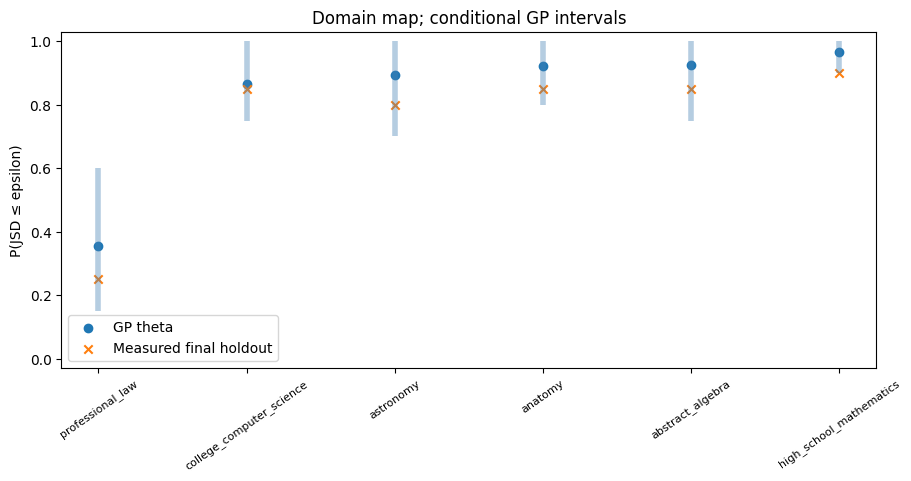

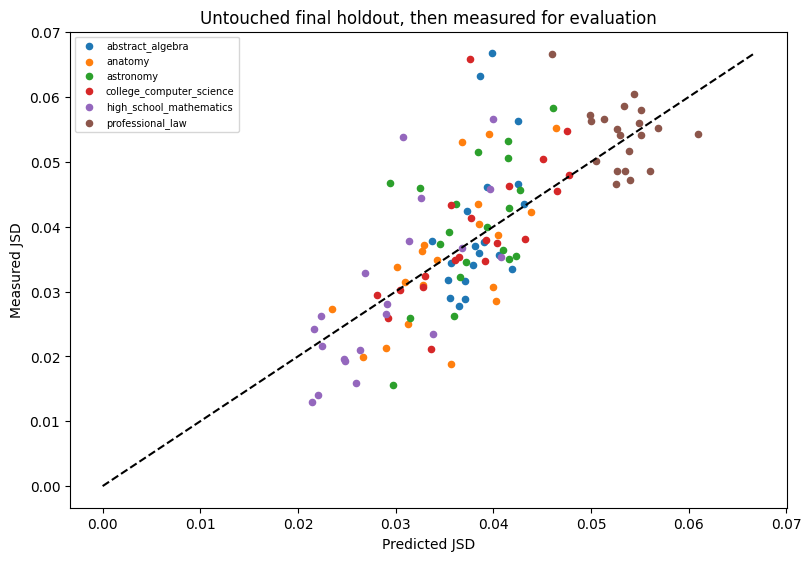

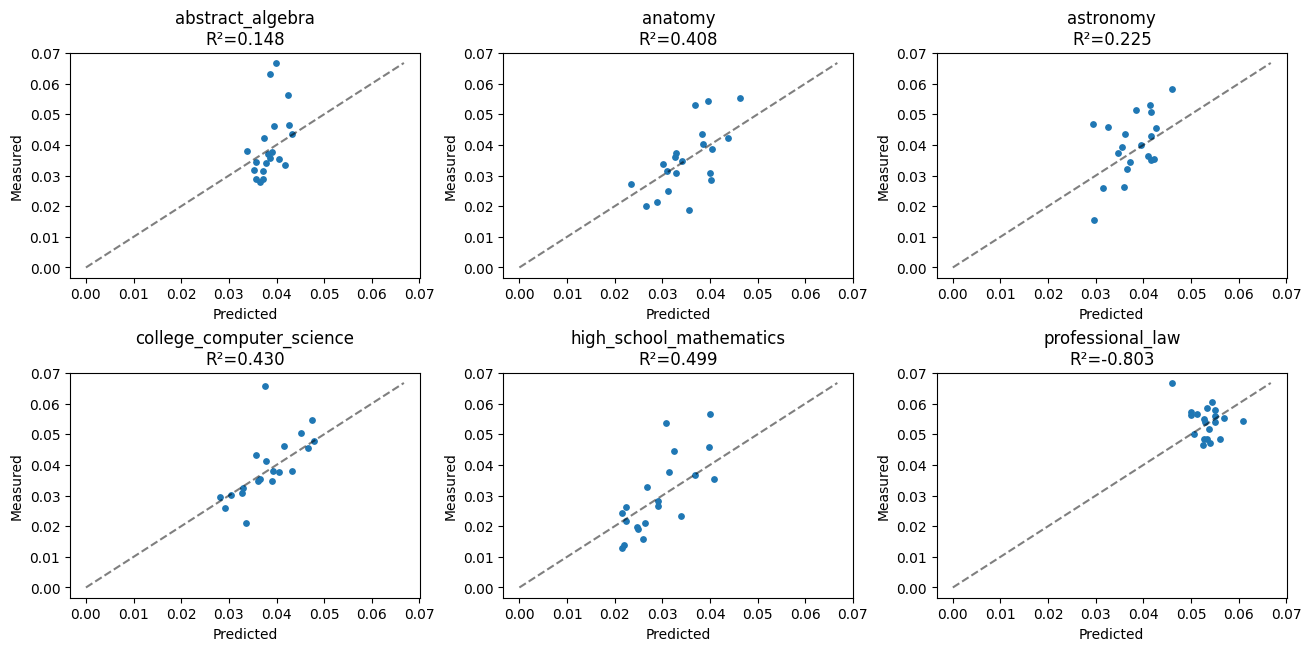

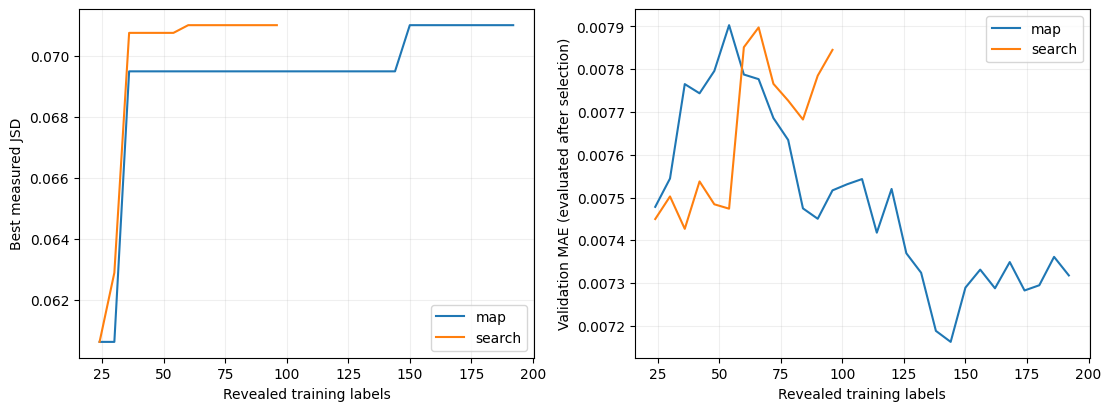

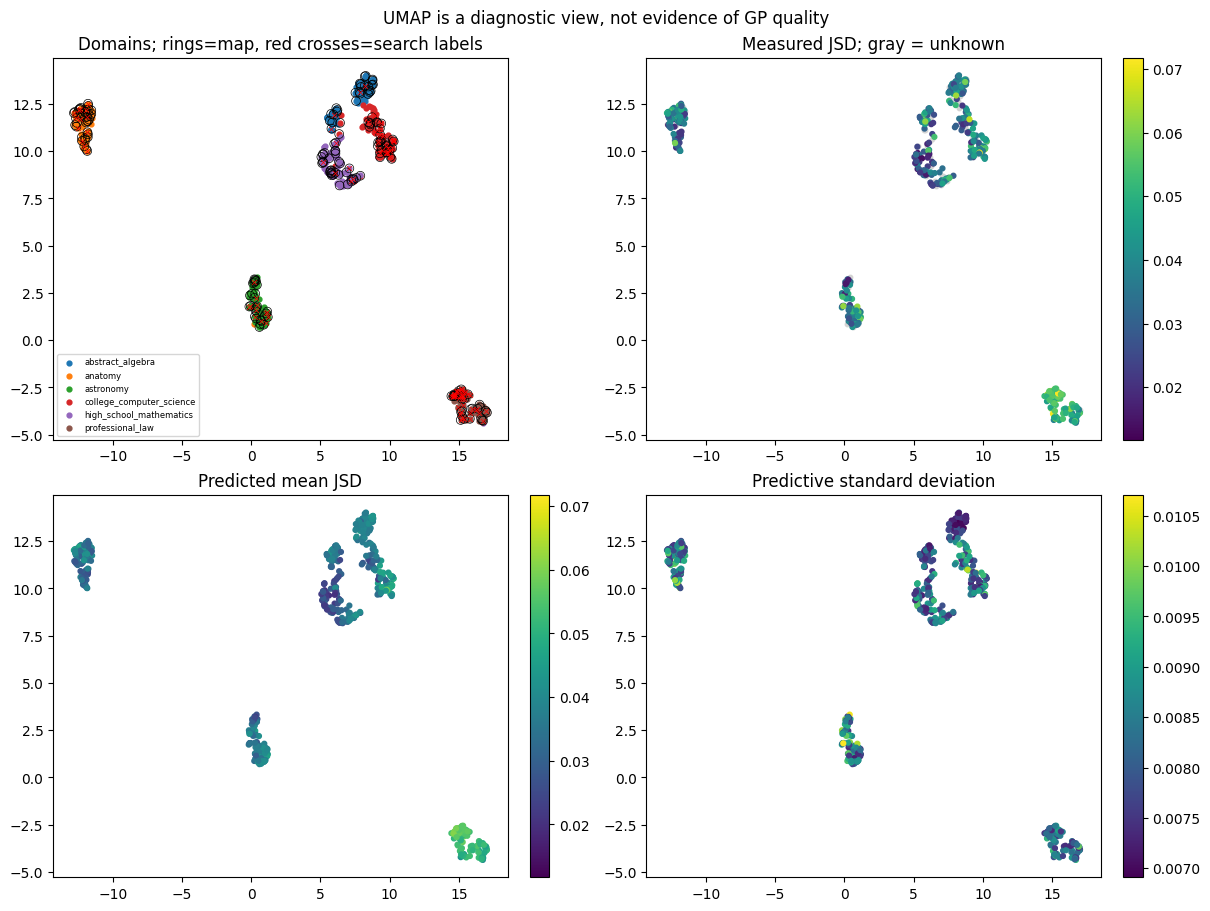

In [11]:
with threadpool_limits(limits=1):show_task(task)

## 9. Необязательная проверка больших target

`large_target_test=True` запускает маленький CPU-тест конечных значений семейства 1+s·exp(x), включая значения порядка 10¹³. Он не использует Qwen и не измеряет дополнительные тексты. Успех synthetic log не означает, что log улучшит JSD. Буквальные ±∞ в GP не передаются.

In [12]:
def large_target_probe():
    train=np.linspace(-2,2,24)[:,None]
    test=np.r_[np.linspace(-1.95,1.95,31),np.linspace(2.1,3,10)][:,None]
    rows=[]
    for scale in [1,1e3,1e6,1e12]:
        y=1+scale*np.exp(train[:,0]);truth=1+scale*np.exp(test[:,0])
        for mode in ['raw','log_shift']:
            target=y if mode=='raw' else np.log(y-1+1e-8)
            gp=GaussianProcessRegressor(kernel=RBF(1.,(.1,10)),alpha=1e-6,normalize_y=True,random_state=42)
            with threadpool_limits(limits=1),warnings.catch_warnings(record=True) as caught:
                gp.fit(train,target);mu,sigma=gp.predict(test,return_std=True)
            prediction=mu if mode=='raw' else 1+np.exp(mu+sigma**2/2)-1e-8
            assert np.isfinite(prediction).all() and np.isfinite(sigma).all()
            rows.append(dict(scale=scale,transform=mode,train_max=float(y.max()),test_max=float(truth.max()),
                finite=True,kernel=str(gp.kernel_),warnings=[str(w.message) for w in caught],
                mae=float(np.abs(truth-prediction).mean()),r2=float(1-np.sum((truth-prediction)**2)/np.sum((truth-truth.mean())**2)),
                interpolation_mae=float(np.abs(truth[:31]-prediction[:31]).mean()),
                extrapolation_mae=float(np.abs(truth[31:]-prediction[31:]).mean()),
                extrapolation_relative_mae=float(np.mean(np.abs(truth[31:]-prediction[31:])/truth[31:])),
                below_one_fraction=float(np.mean(prediction<1))))
    return dict(scope='Finite observations of an unbounded family; not literal infinity or Qwen results',rows=rows)
if config['large_target_test']:
    with threadpool_limits(limits=1):large=large_target_probe()
    save_json(task.out/'large_targets.json',large);display(pd.DataFrame(large['rows']))
else:print('Large-target check disabled for the normal live run.')

Large-target check disabled for the normal live run.


## 10. Сохранить результат

Сохраняются конфиг/ревизии, тексты, признаки, split, **только измеренные** JSD с индексами, решения каждой ветки, прогнозы, θ/интервалы, худший домен, полные найденные тексты, диагностика, графики и стоимость. Никаких pickle-моделей не требуется для проверки.


In [13]:
import shutil
task = _TASKS.get(fingerprint(config))
if task is not None:
    task.save_measurements();task.export_cache();save_json(task.out/'costs.json',task.costs())
archive=shutil.make_archive(str(Path(config['output_dir']).parent/'qwen_task2_product_results'),'zip',config['output_dir'])
print('Saved:',archive)
try:
    from google.colab import files
except ImportError:
    files=None
if files is not None:files.download(archive)

Saved: /content/qwen_task2_product_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



Карта отвечает «в каком домене расхождение вероятнее», поиск — «какие конкретные тексты удалось найти». UCB не гарантирует улучшение карты. При `validate=False` нет измеренной оценки качества; при `True` смотрите и общий R², и ошибки внутри предметов. Успешное выполнение кода само по себе не доказывает высокую точность.

В предыдущих экспериментах наиболее убедительные результаты были получены для Qwen-признаков и общего GP. Полная исследовательская сетка в этом ноутбуке повторно не запускается. Кластерный и случайный варианты начального отбора доступны через настройки.